# Spam Classifier

## Preparing the Train/Test Data

### Hyperparameters

In [1]:
strip_off_email_headers = True
lower_case = True
remove_punctuation = True
replace_urls_with_URL = True
replace_numbers_with_NUMBER = True
do_stemming = True

### Count Unique Words

In [2]:
import os
import random
import re
import string

import nltk
from nltk.stem import PorterStemmer

from email import policy
from email.parser import BytesParser
from bs4 import BeautifulSoup

folders = ["20030228_hard_ham\\hard_ham", "20030228_easy_ham\\easy_ham", "20030228_easy_ham_2\\easy_ham_2",
          "20030228_spam\\spam", "20030228_spam_2\\spam_2"]

exclude = {"cmds"}
unique_words = set()

for folder in folders:

    files = [
    f for f in os.listdir(folder)
    if f not in exclude
    ]

    random.seed(42)
    random.shuffle(files)
    
    for i in range(int(len(files) * 80/100)):
        with open(folder + "\\" + files[i], "rb") as f:
            msg = BytesParser(policy=policy.default).parse(f)

        # Extract only the headers you actually need
        subject = msg.get("Subject", "")
        sender = msg.get("From", "")
        date = msg.get("Date", "")

        headers = "\n".join([
        f"Subject: {subject}",
        f"From: {sender}",
        f"Date: {date}"
        ])
        # Body
        body = msg.get_body(preferencelist=("html", "plain"))

        if body:
            payload = body.get_payload(decode=True)

            charset = body.get_content_charset()

            if not charset or charset.upper() in ("DEFAULT", "UNKNOWN-8BIT"):
                charset = "utf-8"

            try:
                content = payload.decode(charset, errors="replace")
            except (LookupError, UnicodeDecodeError):
                content = payload.decode("latin-1", errors="replace")

            if body.get_content_type() == "text/html":
                content = BeautifulSoup(content, "html.parser").get_text(
                separator="\n", strip=True
            )
        else:
            content = ""

        # Combine headers and body
        text = ""
        if not strip_off_email_headers:
            if remove_punctuation:
                headers = headers.translate(str.maketrans("", "", string.punctuation))
            if replace_urls_with_URL:
                headers = re.sub(
                        r'https?://\S+|www\.\S+',
                        'URL',
                        headers
                        )
            if replace_numbers_with_NUMBER:
                headers = re.sub(r'\b\d+(?:\.\d+)?\b', 'NUMBER', headers)
            text += headers + "\n"

        if remove_punctuation:
            content = content.translate(str.maketrans("", "", string.punctuation))
        if replace_urls_with_URL:
                content = re.sub(
                        r'https?://\S+|www\.\S+',
                        'URL',
                        content
                        )
        if replace_numbers_with_NUMBER:
                content = re.sub(r'\b\d+(?:\.\d+)?\b', 'NUMBER', content)
        text += content

        # Extract words and add them to the set
        if lower_case:
            words = re.findall(r"\b\w+\b", text.lower())
        else:
            words = re.findall(r"\b\w+\b", text)

        if do_stemming:
            stemmer = PorterStemmer()
            stemmed_words = [stemmer.stem(word) for word in words]
            unique_words.update(stemmed_words)
        else:
            unique_words.update(words)


### Create Feature Vectors

In [3]:
import os
import random
import re
import string

import nltk
from nltk.stem import PorterStemmer

from email import policy
from email.parser import BytesParser
from bs4 import BeautifulSoup

folders = ["20030228_hard_ham\\hard_ham", "20030228_easy_ham\\easy_ham", "20030228_easy_ham_2\\easy_ham_2",
          "20030228_spam\\spam", "20030228_spam_2\\spam_2"]

exclude = {"cmds"}

X_train = []
X_test = []
y_train = []
y_test = []

words_list = list(unique_words)

for folder in folders:

    files = [
    f for f in os.listdir(folder)
    if f not in exclude
    ]

    random.seed(42)
    random.shuffle(files)

    length_first_80 = len(files) * 80 / 100
    
    for i in range(len(files)):
        with open(folder + "\\" + files[i], "rb") as f:
            msg = BytesParser(policy=policy.default).parse(f)

        # Extract only the headers you actually need
        subject = msg.get("Subject", "")
        sender = msg.get("From", "")
        date = msg.get("Date", "")

        headers = "\n".join([
        f"Subject: {subject}",
        f"From: {sender}",
        f"Date: {date}"
        ])
        
        # Body
        body = msg.get_body(preferencelist=("html", "plain"))

        if body:
            payload = body.get_payload(decode=True)

            charset = body.get_content_charset()

            if not charset or charset.upper() in ("DEFAULT", "UNKNOWN-8BIT"):
                charset = "utf-8"

            try:
                content = payload.decode(charset, errors="replace")
            except (LookupError, UnicodeDecodeError):
                content = payload.decode("latin-1", errors="replace")

            if body.get_content_type() == "text/html":
                content = BeautifulSoup(content, "html.parser").get_text(
                separator="\n", strip=True
            )
        else:
            content = ""

        # Combine headers and body
        text = ""
        if not strip_off_email_headers:
            if remove_punctuation:
                headers = headers.translate(str.maketrans("", "", string.punctuation))
            if replace_urls_with_URL:
                headers = re.sub(
                        r'https?://\S+|www\.\S+',
                        'URL',
                        headers
                        )
            if replace_numbers_with_NUMBER:
                headers = re.sub(r'\b\d+(?:\.\d+)?\b', 'NUMBER', headers)
            text += headers + "\n"

        if remove_punctuation:
            content = content.translate(str.maketrans("", "", string.punctuation))
        if replace_urls_with_URL:
                content = re.sub(
                        r'https?://\S+|www\.\S+',
                        'URL',
                        content
                        )
        if replace_numbers_with_NUMBER:
                content = re.sub(r'\b\d+(?:\.\d+)?\b', 'NUMBER', content)
        text += content

        # Extract words and add them to the set
        if lower_case:
            words = re.findall(r"\b\w+\b", text.lower())
        else:
            words = re.findall(r"\b\w+\b", text)

        if do_stemming:
            stemmer = PorterStemmer()
            stemmed_words = [stemmer.stem(word) for word in words]
            words = stemmed_words
            
        feature_vector = [0] * len(unique_words)

        for word in words:
            if word in words_list:
                index = words_list.index(word)
                feature_vector[index] = feature_vector[index] + 1
            
        if i < length_first_80:
            X_train.append(feature_vector)
            if "spam" in folder:
                y_train.append(1)
            else:
                y_train.append(0)
        
        else:
            X_test.append(feature_vector)
            if "spam" in folder:
                y_test.append(1)
            else:
                y_test.append(0)

## Standardize Feature Vectors

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

## Training

### Random Forest Classifier

In [5]:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(random_state=42)

### Measuring accuracy using cross-validation

In [6]:
from sklearn.model_selection import cross_val_score
cross_val_score(forest_clf, X_train_scaled, y_train, cv=5, scoring="accuracy").mean()

np.float64(0.9549499175263019)

### Choosing the threshold for classification

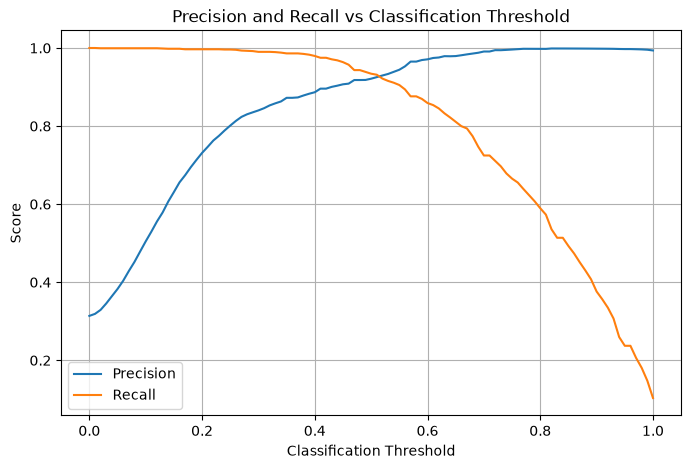

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

from sklearn.model_selection import cross_val_predict

y_train_proba_cv = cross_val_predict(
    forest_clf,
    X_train_scaled,
    y_train,
    cv=5,
    method="predict_proba"
)[:, 1]

thresholds = np.linspace(0, 1, 101)

precisions = []
recalls = []

for threshold in thresholds:
    y_train_pred = (y_train_proba_cv >= threshold).astype(int)

    precisions.append(precision_score(y_train, y_train_pred, zero_division=0))
    recalls.append(recall_score(y_train, y_train_pred, zero_division=0))

plt.figure(figsize=(8, 5))

plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Classification Threshold")
plt.legend()
plt.grid()
plt.show()

In [21]:
for threshold, precision, recall in zip(thresholds, precisions, recalls):
    if precision >= 0.90:
        print(
            f"Threshold: {threshold:.2f}, "
            f"Precision: {precision:.3f}, "
            f"Recall: {recall:.3f}"
        )

Threshold: 0.43, Precision: 0.900, Recall: 0.971
Threshold: 0.44, Precision: 0.904, Recall: 0.968
Threshold: 0.45, Precision: 0.907, Recall: 0.964
Threshold: 0.46, Precision: 0.909, Recall: 0.957
Threshold: 0.47, Precision: 0.918, Recall: 0.943
Threshold: 0.48, Precision: 0.918, Recall: 0.943
Threshold: 0.49, Precision: 0.918, Recall: 0.939
Threshold: 0.50, Precision: 0.921, Recall: 0.934
Threshold: 0.51, Precision: 0.925, Recall: 0.931
Threshold: 0.52, Precision: 0.930, Recall: 0.922
Threshold: 0.53, Precision: 0.934, Recall: 0.916
Threshold: 0.54, Precision: 0.939, Recall: 0.911
Threshold: 0.55, Precision: 0.944, Recall: 0.905
Threshold: 0.56, Precision: 0.953, Recall: 0.894
Threshold: 0.57, Precision: 0.965, Recall: 0.876
Threshold: 0.58, Precision: 0.965, Recall: 0.876
Threshold: 0.59, Precision: 0.969, Recall: 0.870
Threshold: 0.60, Precision: 0.971, Recall: 0.859
Threshold: 0.61, Precision: 0.974, Recall: 0.854
Threshold: 0.62, Precision: 0.976, Recall: 0.845
Threshold: 0.63, Pre

We choose 0.45 as threshold where precision is 90.7% and recall is 96.4% 

In [22]:
threshold = 0.45

## Testing (Precision and Recall)

In [23]:
scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test)

forest_clf.fit(X_train_scaled, y_train)

y_test_proba = forest_clf.predict_proba(X_test_scaled)[:, 1]
y_test_pred = (y_test_proba >= threshold).astype(int)

from sklearn.metrics import precision_score, recall_score

print(precision_score(y_test, y_test_pred, zero_division=0))
print(recall_score(y_test, y_test_pred, zero_division=0))

0.9732620320855615
0.9604221635883905


For threshold = 0.45, the precision is 97.3% and the recall is 96% on the testing data.